# Export surface parameters
- This script is used to export urban fraction and prescribed roof albedo.

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
home_path = '/gws/ssde/j25a/duicv/yuansun/'

In [6]:
domain = 'HK'
surfdata_file_date = '250811'
albedo_date = '250812'
sum_roof_albedo_area_list = []
file_date = surfdata_file_date
albedo_date = albedo_date
ds_mask = xr.open_dataset(f'{home_path}0_wrf-cstm_GM-HK/{domain}/mask/mask_{domain}.nc')
ds_surf = xr.open_dataset(f'{home_path}0_wrf-cstm_GM-HK/{domain}/surface_data/usurf/Usurf_surfdata_{domain}_1.2x1.2_SSP5-8.5_2035_78pfts_c{file_date}.nc')
urban_area = 1.44 * ds_surf['PCT_URBAN'][2] / 100 # * ds_surf['LANDFRAC_PFT'], lnd_frac = 1
roof_area = (urban_area * ds_surf['WTLUNIT_ROOF'][2]).where(ds_mask['mask'], 0)
ds_albedo_stream = xr.open_dataset(f'{home_path}0_wrf-cstm_GM-HK/{domain}/surface_data/usurf/dyn_alb_roof_{domain}_1.2x1.2_2034-2042_c{albedo_date}.nc')
roof_albedo_tv = ds_albedo_stream['dyn_alb_roof_MD']
roof_albedo_tv_modified = roof_albedo_tv.rename({'lat': 'lsmlat', 'lon': 'lsmlon'}).assign_coords({'lsmlat': ds_mask.lsmlat, 'lsmlon': ds_mask.lsmlon})
ds_albedo_stream_last = roof_albedo_tv_modified[-1].where(urban_area>0)
ds_albedo_stream_first = roof_albedo_tv_modified[0].where(urban_area>0)
ds_albedo_stream_last_modified = ds_albedo_stream_last.rename({'lsmlat': 'lat', 'lsmlon': 'lon'}).assign_coords({'lat': roof_albedo_tv.lat, 'lon': roof_albedo_tv.lon})
ds_albedo_stream_first_modified = ds_albedo_stream_first.rename({'lsmlat': 'lat', 'lsmlon': 'lon'}).assign_coords({'lat': roof_albedo_tv.lat, 'lon': roof_albedo_tv.lon})
ds_albedo_stream_last_modified.to_netcdf(f'data_for_figure/roof_albedo_last_{domain}.nc')
ds_albedo_stream_first_modified.to_netcdf(f'data_for_figure/roof_albedo_first_{domain}.nc')
roof_area_albedo = (roof_area * roof_albedo_tv_modified).where(ds_mask['mask'])
sum_roof_albedo_area = roof_area_albedo.sum(dim=['lsmlat', 'lsmlon'])
df_sum_roof_albedo_area = sum_roof_albedo_area.to_dataframe('sum_roof_albedo_area').reset_index()
df_sum_roof_albedo_area['domain'] = domain
df_sum_roof_albedo_area['time'] = pd.to_datetime(df_sum_roof_albedo_area['time'], format='%Y-%m-%d %H:%M:%S')
df_sum_roof_albedo_area.to_csv('data_for_figure/sum_roof_albedo_area.csv', index=False)
df_sum_roof_albedo_area.head()

,time,sum_roof_albedo_area,domain
0,2034-01-01,4.810689,HK
1,2034-02-01,4.810689,HK
2,2034-03-01,4.810689,HK
3,2034-04-01,4.810689,HK
4,2034-05-01,4.810689,HK


<Axes: xlabel='time'>

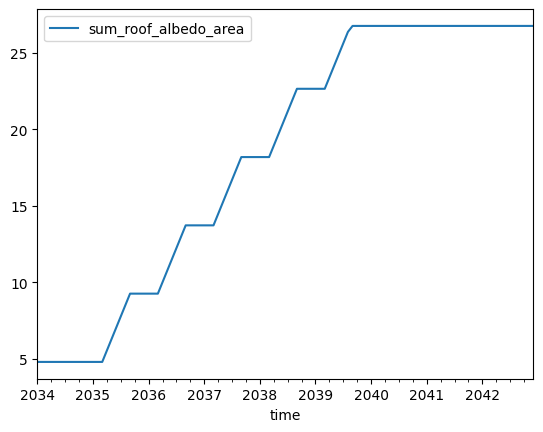

In [7]:
df_sum_roof_albedo_area.plot(x='time', y='sum_roof_albedo_area')